# Lab 3 — Additional Task (Level 1): Automatic Speech Translation
**Whisper fine-tuning: English audio → Ukrainian text**

**Dataset:** Google FLEURS (`en_us` audio + `uk_ua` translations as target)
**Model:** `openai/whisper-tiny` fine-tuned with PyTorch Lightning
**Metric:** COMET (main AST metric — neural semantic translation quality)

The goal of this notebook is to build a **working Automatic Speech Translation (AST) pipeline** for the **Level 1 additional task**.

The model takes **English speech audio** as input and generates **Ukrainian text** as output.
This experiment demonstrates the **correctness and usability of the pipeline**, not the best possible quality.

Main steps:
1. Load a multilingual speech dataset
2. Prepare audio-text pairs for AST
3. Fine-tune a pretrained Whisper model with PyTorch Lightning
4. Evaluate the model with **COMET** (Unbabel/wmt22-comet-da) using `src`, `ref`, `hyp` files

## 1. Install Dependencies

In [1]:
import subprocess, sys

pkgs_to_remove = [
    "torch", "torchvision", "torchaudio",
    "pytorch-lightning", "lightning", "torchmetrics",
    "unbabel-comet",
]
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y"] + pkgs_to_remove,
               capture_output=True)

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "numpy<2.0",
    "torch==2.6.0",
    "torchvision==0.21.0",
    "torchaudio==2.6.0",
    "pytorch-lightning==2.5.0",
    "transformers==4.51.3",
    "datasets==3.5.0",
    "accelerate==1.6.0",
    "matplotlib",
    "pandas",
    "pyyaml",
], check=True)

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "unbabel-comet==2.2.4",
    "--no-deps",
], check=True)

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "sentencepiece", "sacrebleu", "jsonargparse",
    "lightning-utilities", "entmax",
], check=True)

print("done")

done


## 2. Imports & Environment

In [2]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import torch
import torchaudio
import pytorch_lightning as pl
from datasets import load_dataset, DatasetDict, Dataset as HFDataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    get_linear_schedule_with_warmup,
)
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

PROJECT_ROOT = Path(".").resolve()
CACHE_DIR = PROJECT_ROOT / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))

print("torch    :", torch.__version__)
print("lightning:", pl.__version__)
print("CUDA     :", torch.cuda.is_available())

torch    : 2.6.0+cu124
lightning: 2.5.0
CUDA     : True


## 3. Dataset

**Google FLEURS** — aligned speech+text across many languages.
- Audio: English (`en_us`)
- Target text: Ukrainian (`uk_ua`) translation

Sentences are n-way parallel in FLEURS, so index `i` in `en_us` matches index `i` in `uk_ua`.

In [3]:
ds_en_peek = load_dataset("google/fleurs", "en_us", split="train[:2%]", trust_remote_code=True)
ds_uk_peek = load_dataset("google/fleurs", "uk_ua", split="train[:2%]", trust_remote_code=True)

print("Dataset info:", ds_en_peek)
print("\n=== Parallel sentence examples ===")
for i in range(3):
    print(f"[{i}] EN: {ds_en_peek[i]['transcription']}")
    print(f"     UK: {ds_uk_peek[i]['transcription']}")
    dur = len(ds_en_peek[i]['audio']['array']) / ds_en_peek[i]['audio']['sampling_rate']
    print(f"     Duration: {dur:.1f}s")
    print()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset info: Dataset({
    features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
    num_rows: 52
})

=== Parallel sentence examples ===
[0] EN: a tornado is a spinning column of very low-pressure air which sucks the surrounding air inward and upward
     UK: це перший випадок коли було висунуто обвинувачення відповідно до закону прийнятого у 2003 році з метою обмеження розсилки електронних листів користувачам тобто спама від небажаних відправників
     Duration: 6.8s

[1] EN: former u.s. speaker of the house newt gingrich came in second with 32%
     UK: леслі аун спікер фонду комен повідомила що організація розробила нове правило що не дозволяє надавати гранти або фінансування організаціям щодо яких ведеться розслідування
     Duration: 7.7s

[2] EN: the island was first inhabited by the taínos and caribes. the caribes were an arawakan-speaking people who had arrived around 10,000 bce
     UK: у міні

## 4. Audio Visualization

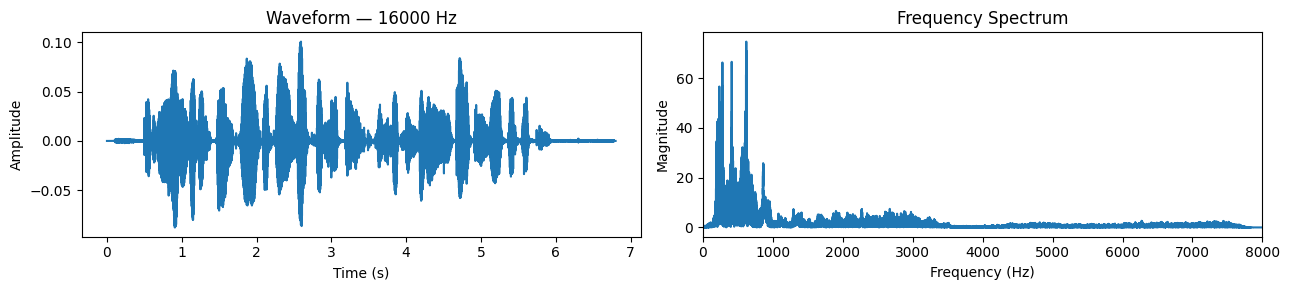

EN: a tornado is a spinning column of very low-pressure air which sucks the surrounding air inward and upward


In [4]:
import matplotlib.pyplot as plt
import numpy as np

sample = ds_en_peek[0]
audio_array = sample['audio']['array']
sr = sample['audio']['sampling_rate']
times = np.arange(len(audio_array)) / sr

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(times, audio_array)
axes[0].set_title(f"Waveform — {sr} Hz")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

freqs = np.fft.rfftfreq(len(audio_array), d=1.0/sr)
fft_mag = np.abs(np.fft.rfft(audio_array))
axes[1].plot(freqs, fft_mag)
axes[1].set_xlim(0, 8000)
axes[1].set_title("Frequency Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()
print(f"EN: {sample['transcription']}")

## 5. Config

In [5]:
CONFIG = {
    "seed": 42,
    "output_dir": "./outputs_ast",
    "data": {
        "dataset_name": "google/fleurs",
        "source_lang": "en_us",
        "target_lang": "uk_ua",
        "audio_column": "audio",
        "source_text_column": "transcription",
        "target_text_column": "translation",
        "sample_id_column": "sample_id",
        "sample_rate": 16000,
        "num_workers": 0,
    },
    "model": {
        "name": "openai/whisper-tiny",
        "target_language": "uk",
        "generation_task": "transcribe",
        "max_output_tokens": 128,
        "num_beams": 1,
        "freeze_encoder": False,
        "gradient_checkpointing": False,
    },
    "training": {
        "batch_size": 4,
        "eval_batch_size": 4,
        "learning_rate": 1e-5,
        "weight_decay": 0.01,
        "warmup_steps": 0,
        "max_epochs": 3,
        "precision": "32-true",
        "accumulate_grad_batches": 1,
        "gradient_clip_val": 1.0,
        "log_every_n_steps": 5,
        "limit_train_batches": 1.0,
        "limit_val_batches": 1.0,
    },
}

output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'output_dir': './outputs_ast',
 'data': {'dataset_name': 'google/fleurs',
  'source_lang': 'en_us',
  'target_lang': 'uk_ua',
  'audio_column': 'audio',
  'source_text_column': 'transcription',
  'target_text_column': 'translation',
  'sample_id_column': 'sample_id',
  'sample_rate': 16000,
  'num_workers': 0},
 'model': {'name': 'openai/whisper-tiny',
  'target_language': 'uk',
  'generation_task': 'transcribe',
  'max_output_tokens': 128,
  'num_beams': 1,
  'freeze_encoder': False,
  'gradient_checkpointing': False},
 'training': {'batch_size': 4,
  'eval_batch_size': 4,
  'learning_rate': 1e-05,
  'weight_decay': 0.01,
  'warmup_steps': 0,
  'max_epochs': 3,
  'precision': '32-true',
  'accumulate_grad_batches': 1,
  'gradient_clip_val': 1.0,
  'log_every_n_steps': 5,
  'limit_train_batches': 1.0,
  'limit_val_batches': 1.0}}

## 6. DataModule

In [6]:
def to_mono_float32(waveform: torch.Tensor) -> torch.Tensor:
    if waveform.ndim == 2 and waveform.shape[0] == 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if waveform.ndim == 2:
        waveform = waveform.squeeze(0)
    return waveform.float()


def resample_if_needed(waveform: torch.Tensor, orig_sr: int, target_sr: int) -> torch.Tensor:
    if orig_sr == target_sr:
        return waveform
    return torchaudio.functional.resample(waveform, orig_freq=orig_sr, new_freq=target_sr)


class HFAudioTranslationDataset(TorchDataset):
    def __init__(self, hf_split: Any, data_config: dict[str, Any]) -> None:
        self.dataset = hf_split
        self.audio_column = data_config.get("audio_column", "audio")
        self.target_text_column = data_config.get("target_text_column", "translation")
        self.source_text_column = data_config.get("source_text_column")
        self.sample_id_column = data_config.get("sample_id_column")
        self.sample_rate = int(data_config.get("sample_rate", 16000))

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> dict[str, Any]:
        row = self.dataset[index]
        audio_info = row[self.audio_column]
        waveform = torch.as_tensor(audio_info["array"], dtype=torch.float32)
        waveform = to_mono_float32(waveform)
        waveform = resample_if_needed(waveform, int(audio_info["sampling_rate"]), self.sample_rate)
        sample_id = row.get(self.sample_id_column, f"sample{index}") if self.sample_id_column else f"sample{index}"
        return {
            "sample_id": sample_id,
            "audio": waveform.numpy(),
            "sampling_rate": self.sample_rate,
            "target_text": row[self.target_text_column],
            "source_text": row.get(self.source_text_column) if self.source_text_column else None,
        }


class WhisperASTCollator:
    def __init__(self, processor: Any, target_language: str, generation_task: str, sample_rate: int) -> None:
        self.processor = processor
        self.feature_extractor = processor.feature_extractor
        self.tokenizer = processor.tokenizer
        self.tokenizer.set_prefix_tokens(language=target_language, task=generation_task)

    def __call__(self, features: list[dict[str, Any]]) -> dict[str, Any]:
        input_features, label_features = [], []
        source_texts, target_texts, sample_ids = [], [], []

        for f in features:
            ext = self.feature_extractor(f["audio"], sampling_rate=f["sampling_rate"], return_tensors="pt")
            input_features.append({"input_features": ext.input_features[0]})
            label_features.append({"input_ids": self.tokenizer(f["target_text"]).input_ids})
            source_texts.append(f["source_text"])
            target_texts.append(f["target_text"])
            sample_ids.append(f["sample_id"])

        batch = self.feature_extractor.pad(input_features, return_tensors="pt")
        labels_batch = self.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch["attention_mask"].ne(1), -100)
        batch["labels"] = labels
        batch["source_texts"] = source_texts
        batch["target_texts"] = target_texts
        batch["sample_ids"] = sample_ids
        return batch


def build_ast_split(split_name: str, max_samples: int | None = None) -> HFDataset:
    en = load_dataset("google/fleurs", "en_us", split=split_name, trust_remote_code=True)
    uk = load_dataset("google/fleurs", "uk_ua", split=split_name, trust_remote_code=True)
    uk_by_id = {row["id"]: row["transcription"] for row in uk}
    records = []
    for row in en:
        uk_text = uk_by_id.get(row["id"])
        if uk_text is None:
            continue
        records.append({
            "sample_id": f"fleurs_{split_name}_{row['id']}",
            "audio": row["audio"],
            "transcription": row["transcription"],
            "translation": uk_text,
        })
        if max_samples and len(records) >= max_samples:
            break
    return HFDataset.from_list(records)


print("Building train split...")
train_ds = build_ast_split("train", max_samples=130)
print("Building validation split...")
val_ds = build_ast_split("validation", max_samples=60)
print("Building test split...")
test_ds = build_ast_split("test", max_samples=60)

ast_dataset = DatasetDict(train=train_ds, validation=val_ds, test=test_ds)
print(ast_dataset)

Building train split...
Building validation split...
Building test split...
DatasetDict({
    train: Dataset({
        features: ['sample_id', 'audio', 'transcription', 'translation'],
        num_rows: 130
    })
    validation: Dataset({
        features: ['sample_id', 'audio', 'transcription', 'translation'],
        num_rows: 60
    })
    test: Dataset({
        features: ['sample_id', 'audio', 'transcription', 'translation'],
        num_rows: 60
    })
})


## 7. Model & Dataloaders

In [7]:
pl.seed_everything(CONFIG["seed"])

model_cfg = CONFIG["model"]
data_cfg = CONFIG["data"]
train_cfg = CONFIG["training"]

processor = WhisperProcessor.from_pretrained(
    model_cfg["name"],
    language=model_cfg["target_language"],
    task=model_cfg["generation_task"],
)

collator = WhisperASTCollator(
    processor=processor,
    target_language=model_cfg["target_language"],
    generation_task=model_cfg["generation_task"],
    sample_rate=data_cfg["sample_rate"],
)

train_loader = DataLoader(
    HFAudioTranslationDataset(ast_dataset["train"], data_cfg),
    batch_size=train_cfg["batch_size"],
    shuffle=True,
    collate_fn=collator,
    num_workers=data_cfg["num_workers"],
)
val_loader = DataLoader(
    HFAudioTranslationDataset(ast_dataset["validation"], data_cfg),
    batch_size=train_cfg["eval_batch_size"],
    shuffle=False,
    collate_fn=collator,
    num_workers=data_cfg["num_workers"],
)
test_loader = DataLoader(
    HFAudioTranslationDataset(ast_dataset["test"], data_cfg),
    batch_size=train_cfg["eval_batch_size"],
    shuffle=False,
    collate_fn=collator,
    num_workers=data_cfg["num_workers"],
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Train batches : 33
Val batches   : 15
Test batches  : 15


## 8. Lightning Module

In [8]:
class WhisperASTModule(pl.LightningModule):
    def __init__(self, config: dict, processor: Any) -> None:
        super().__init__()
        self.config = config
        self.processor = processor
        m_cfg = config["model"]

        self.model = WhisperForConditionalGeneration.from_pretrained(m_cfg["name"])
        self.model.config.forced_decoder_ids = None
        self.model.config.suppress_tokens = []

        if m_cfg.get("gradient_checkpointing"):
            self.model.gradient_checkpointing_enable()

        self._pred_dir = Path(config["output_dir"]) / "predictions"
        self._pred_dir.mkdir(parents=True, exist_ok=True)
        self._test_records: list[dict] = []

    def forward(self, batch):
        return self.model(
            input_features=batch["input_features"],
            labels=batch["labels"],
        )

    def training_step(self, batch, batch_idx):
        loss = self(batch).loss
        self.log("train/loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self(batch).loss
        self.log("val/loss", loss, prog_bar=True)
        return loss

    def _generate_predictions(self, batch):
      m_cfg = self.config["model"]
      with torch.no_grad():
          generated = self.model.generate(
              input_features=batch["input_features"],
              language=m_cfg["target_language"],
              task=m_cfg["generation_task"],
              max_new_tokens=m_cfg["max_output_tokens"],
              num_beams=2,
              no_repeat_ngram_size=3,
              repetition_penalty=1.3,
          )
      predictions = self.processor.tokenizer.batch_decode(generated, skip_special_tokens=True)
      return predictions, batch["target_texts"], batch["source_texts"], batch["sample_ids"]

    def test_step(self, batch, batch_idx):
        predictions, references, source_texts, sample_ids = self._generate_predictions(batch)
        for sid, src, ref, pred in zip(sample_ids, source_texts, references, predictions):
            self._test_records.append({
                "sample_id": sid,
                "src": src,
                "ref": ref,
                "hyp": pred,
            })

    def on_test_epoch_end(self):
        pred_dir = self._pred_dir

        jsonl_path = pred_dir / "test_predictions.jsonl"
        with open(jsonl_path, "w", encoding="utf-8") as f:
            for r in self._test_records:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

        src_path = pred_dir / "src.txt"
        ref_path = pred_dir / "ref.txt"
        hyp_path = pred_dir / "hyp.txt"

        with open(src_path, "w", encoding="utf-8") as f_src, \
             open(ref_path, "w", encoding="utf-8") as f_ref, \
             open(hyp_path, "w", encoding="utf-8") as f_hyp:
            for r in self._test_records:
                f_src.write(r["src"] + "\n")
                f_ref.write(r["ref"] + "\n")
                f_hyp.write(r["hyp"] + "\n")

        print(f"\nTotal test predictions: {len(self._test_records)}")
        print(f"Saved: {src_path}")
        print(f"Saved: {ref_path}")
        print(f"Saved: {hyp_path}")
        print("\n=== Sample Predictions ===")
        for i, r in enumerate(self._test_records[:5], 1):
            print(f"\n[{i}]")
            print(f"  src : {r['src']}")
            print(f"  ref : {r['ref']}")
            print(f"  hyp : {r['hyp']}")

    def configure_optimizers(self):
        t_cfg = self.config["training"]
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=t_cfg["learning_rate"],
            weight_decay=t_cfg["weight_decay"],
        )
        total_steps = self.trainer.estimated_stepping_batches
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=t_cfg["warmup_steps"],
            num_training_steps=total_steps,
        )
        return [optimizer], [{"scheduler": scheduler, "interval": "step"}]


model = WhisperASTModule(CONFIG, processor)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Model parameters: 37.8M


## 9. Baseline Predictions (before training)

In [9]:
pred_dir = output_dir / "predictions"
pred_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.model.to(device)
model.model.eval()

baseline_records = []

for batch in test_loader:
    batch["input_features"] = batch["input_features"].to(device)
    m_cfg = CONFIG["model"]
    with torch.no_grad():
      generated = model.model.generate(
          input_features=batch["input_features"],
          language=m_cfg["target_language"],
          task=m_cfg["generation_task"],
          max_new_tokens=m_cfg["max_output_tokens"],
          num_beams=2,
          no_repeat_ngram_size=3,
          repetition_penalty=1.3,
      )
    predictions = processor.tokenizer.batch_decode(generated, skip_special_tokens=True)
    for sid, src, ref, pred in zip(batch["sample_ids"], batch["source_texts"], batch["target_texts"], predictions):
        baseline_records.append({"sample_id": sid, "src": src, "ref": ref, "hyp": pred})

with open(pred_dir / "baseline_src.txt", "w", encoding="utf-8") as f_src, \
     open(pred_dir / "baseline_ref.txt", "w", encoding="utf-8") as f_ref, \
     open(pred_dir / "baseline_hyp.txt", "w", encoding="utf-8") as f_hyp:
    for r in baseline_records:
        f_src.write(r["src"] + "\n")
        f_ref.write(r["ref"] + "\n")
        f_hyp.write(r["hyp"] + "\n")

print(f"Baseline predictions: {len(baseline_records)} examples")
print(f"Saved: {pred_dir}/baseline_src.txt")
print(f"Saved: {pred_dir}/baseline_ref.txt")
print(f"Saved: {pred_dir}/baseline_hyp.txt")

You have passed task=transcribe, but also have set `forced_decoder_ids` to [[1, None], [2, 50359]] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Baseline predictions: 60 examples
Saved: outputs_ast/predictions/baseline_src.txt
Saved: outputs_ast/predictions/baseline_ref.txt
Saved: outputs_ast/predictions/baseline_hyp.txt


## 10. Training

In [10]:
t_cfg = CONFIG["training"]

logger = CSVLogger(save_dir=str(output_dir), name="logs")
lr_monitor = LearningRateMonitor(logging_interval="step")
checkpoint_cb = ModelCheckpoint(
    dirpath=str(output_dir / "checkpoints"),
    filename="best",
    monitor="val/loss",
    mode="min",
    save_top_k=1,
)

trainer = pl.Trainer(
    max_epochs=t_cfg["max_epochs"],
    precision=t_cfg["precision"],
    accumulate_grad_batches=t_cfg["accumulate_grad_batches"],
    gradient_clip_val=t_cfg["gradient_clip_val"],
    log_every_n_steps=t_cfg["log_every_n_steps"],
    limit_train_batches=t_cfg["limit_train_batches"],
    limit_val_batches=t_cfg["limit_val_batches"],
    logger=logger,
    callbacks=[lr_monitor, checkpoint_cb],
    enable_progress_bar=True,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /content/outputs_ast/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                            | Params | Mode
------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 4. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


## 11. Test Predictions (after training)

In [11]:
model._test_records = []
trainer.test(model, dataloaders=test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]


Total test predictions: 60
Saved: outputs_ast/predictions/src.txt
Saved: outputs_ast/predictions/ref.txt
Saved: outputs_ast/predictions/hyp.txt

=== Sample Predictions ===

[1]
  src : however due to the slow communication channels styles in the west could lag behind by 25 to 30 year
  ref : однак через повільні канали комунікації західні стилі можуть відставати на 25-30 років
  hyp :  Дившлися з кемінікатинцяського шансу та виловлення на 25-30 років

[2]
  src : the cabbage juice changes color depending on how acidic or basic alkaline the chemical is
  ref : сік капусти змінює колір у залежності від того наскільки кислотним чи основним лужним є хімікат
  hyp :  випов'ється дійсною збількою зробити після керпівка та мілька місця істори відповідься до сьогодні

[3]
  src : many people don't think about them as dinosaurs because they have feathers and can fly
  ref : багато людей не думають про них як про динозаврів оскільки вони мають пір'я і можуть літати
  hyp :  Міній місця зонтіка 

[{}]

## 12. COMET Evaluation

COMET evaluates **semantic translation quality** using 3 inputs:
- **`src`** — original English source text
- **`ref`** — reference Ukrainian translation
- **`hyp`** — model hypothesis (generated Ukrainian text)

Model: **Unbabel/wmt22-comet-da** (state-of-the-art reference-based metric).
Score range: 0–1, higher is better (≥ 0.85 is considered good quality).

In [12]:
from comet import download_model, load_from_checkpoint

pred_dir = output_dir / "predictions"


def read_lines(path) -> list[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]


def compute_comet_from_files(src_path, ref_path, hyp_path, comet_model) -> dict:
    src_lines = read_lines(src_path)
    ref_lines = read_lines(ref_path)
    hyp_lines = read_lines(hyp_path)

    comet_input = [
        {"src": s, "ref": r, "mt": h}
        for s, r, h in zip(src_lines, ref_lines, hyp_lines)
    ]
    result = comet_model.predict(
        comet_input,
        batch_size=8,
        gpus=1 if torch.cuda.is_available() else 0,
    )
    return {"comet": float(result.system_score), "num_examples": len(comet_input)}


print("Loading COMET model (Unbabel/wmt22-comet-da)...")
comet_ckpt = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_ckpt)

print("\nEvaluating baseline (zero-shot)...")
baseline_metrics = compute_comet_from_files(
    pred_dir / "baseline_src.txt",
    pred_dir / "baseline_ref.txt",
    pred_dir / "baseline_hyp.txt",
    comet_model,
)

print("Evaluating fine-tuned model...")
trained_metrics = compute_comet_from_files(
    pred_dir / "src.txt",
    pred_dir / "ref.txt",
    pred_dir / "hyp.txt",
    comet_model,
)

comparison = {
    "baseline_comet": baseline_metrics["comet"],
    "trained_comet":  trained_metrics["comet"],
    "delta":          trained_metrics["comet"] - baseline_metrics["comet"],
    "num_examples":   trained_metrics["num_examples"],
}

with open(pred_dir / "comet_comparison.json", "w", encoding="utf-8") as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

print("\n" + "=" * 50)
print("AST COMET EVALUATION RESULTS")
print("=" * 50)
print(f"Baseline COMET : {baseline_metrics['comet']:.4f}")
print(f"Fine-tuned COMET: {trained_metrics['comet']:.4f}")
print(f"Delta           : {comparison['delta']:+.4f}")
print(f"Examples        : {comparison['num_examples']}")

Loading COMET model (Unbabel/wmt22-comet-da)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Evaluating baseline (zero-shot)...


Predicting DataLoader 0: 100%|██████████| 8/8 [00:01<00:00,  5.09it/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating fine-tuned model...


Predicting DataLoader 0: 100%|██████████| 8/8 [00:01<00:00,  5.64it/s]



AST COMET EVALUATION RESULTS
Baseline COMET : 0.3011
Fine-tuned COMET: 0.3147
Delta           : +0.0137
Examples        : 60


## 13. COMET Summary Table

In [13]:
import pandas as pd

comparison_path = output_dir / "predictions" / "comet_comparison.json"

if comparison_path.exists():
    with open(comparison_path, "r", encoding="utf-8") as f:
        comparison = json.load(f)

    df = pd.DataFrame([
        {
            "Stage": "Baseline (zero-shot)",
            "COMET Score": round(comparison["baseline_comet"], 4),
            "Delta vs Baseline": "-",
        },
        {
            "Stage": f"Fine-tuned ({CONFIG['training']['max_epochs']} epochs)",
            "COMET Score": round(comparison["trained_comet"], 4),
            "Delta vs Baseline": f"{comparison['delta']:+.4f}",
        },
    ])

    print("AST COMET Evaluation Results")
    print(df.to_string(index=False))
    print(f"\nTotal examples evaluated: {comparison['num_examples']}")
    print("\nFiles used for COMET:")
    print(f"  src : {output_dir}/predictions/src.txt")
    print(f"  ref : {output_dir}/predictions/ref.txt")
    print(f"  hyp : {output_dir}/predictions/hyp.txt")
else:
    print("comet_comparison.json not found. Run cell 12 first.")

AST COMET Evaluation Results
                Stage  COMET Score Delta vs Baseline
 Baseline (zero-shot)       0.3011                 -
Fine-tuned (3 epochs)       0.3147           +0.0137

Total examples evaluated: 60

Files used for COMET:
  src : outputs_ast/predictions/src.txt
  ref : outputs_ast/predictions/ref.txt
  hyp : outputs_ast/predictions/hyp.txt
